EDA -> Feature Engineering -> Modelling

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
pd.set_option("display.max_columns", None)

In [3]:
sns.set_style("whitegrid")

In [4]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "data" / "german_credit_data.csv").exists():
    project_root = project_root.parent

data_path = project_root / "data" / "german_credit_data.csv"
if not data_path.exists():
    raise FileNotFoundError(f"CSV not found. Looked in: {data_path}")

df = pd.read_csv(data_path)


In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [7]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [8]:
df.shape

(1000, 11)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df["Job"].unique

<bound method Series.unique of 0      2
1      2
2      1
3      2
4      2
      ..
995    1
996    3
997    2
998    2
999    2
Name: Job, Length: 1000, dtype: int64>

In [12]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df=df.dropna().reset_index(drop=True)

In [15]:
df.shape

(522, 11)

##Univariate analysis

In [16]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [17]:
df.drop(columns="Unnamed: 0", inplace=True)

In [18]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [19]:
df.head

<bound method NDFrame.head of      Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0     22  female    2     own          little         moderate           5951   
1     45    male    2    free          little           little           7882   
2     53    male    2    free          little           little           4870   
3     35    male    3    rent          little         moderate           6948   
4     28    male    3     own          little         moderate           5234   
..   ...     ...  ...     ...             ...              ...            ...   
517   48    male    1     own          little         moderate           1743   
518   30    male    3     own          little           little           3959   
519   40    male    3     own          little           little           3857   
520   23    male    2    free          little           little           1845   
521   27    male    2     own        moderate         moderate           4576  

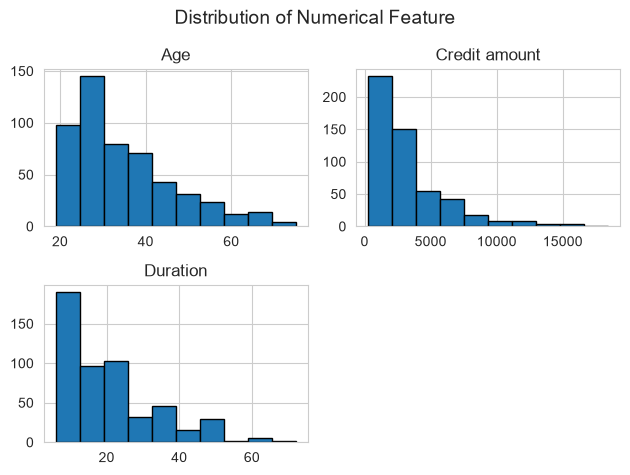

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

df[["Age", "Credit amount", "Duration"]].hist(bins=10, edgecolor="black")
plt.suptitle("Distribution of Numerical Feature", fontsize=14)
plt.tight_layout()
plt.show()

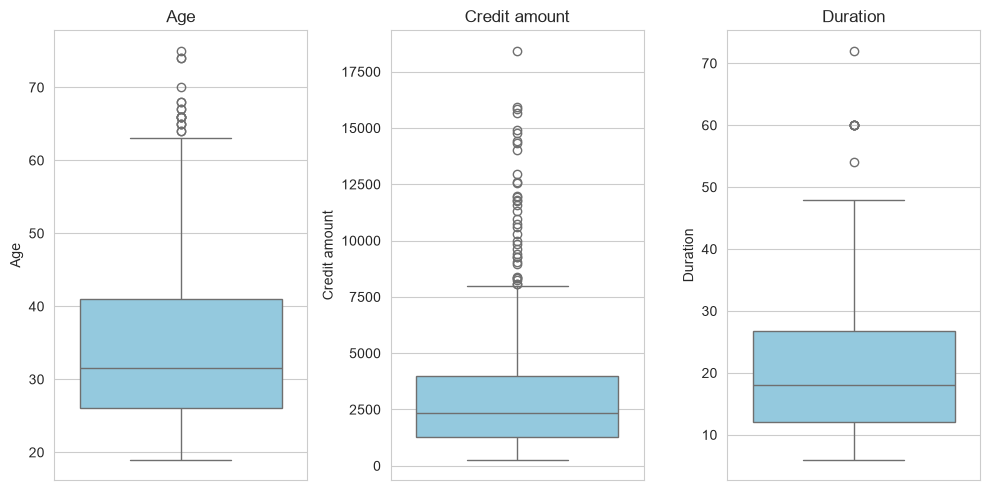

In [35]:
plt.figure(figsize=(10,5))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [32]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\2614473645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette="Set2", order=df[col].value_counts().index)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\2614473645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette="Set2", order=df[col].value_counts().index)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\2614473645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette="Set2", order=df[col].value_counts().index)
C:\User

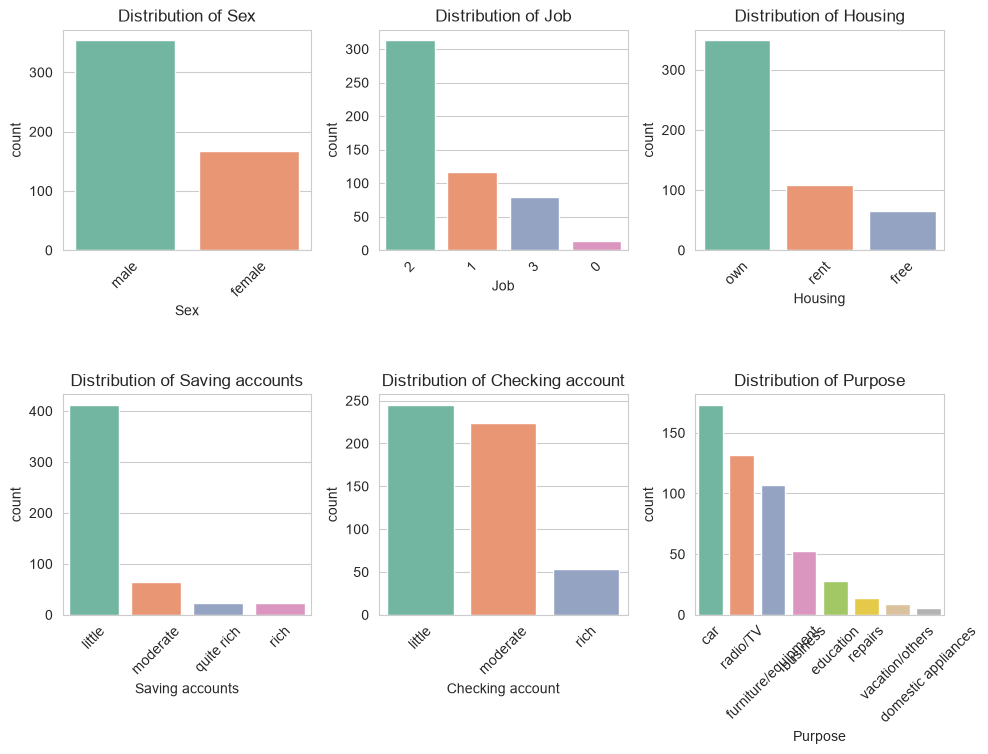

In [41]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,palette="Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
corr=df[["Age","Job","Credit amount","Duration"]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


<Axes: >

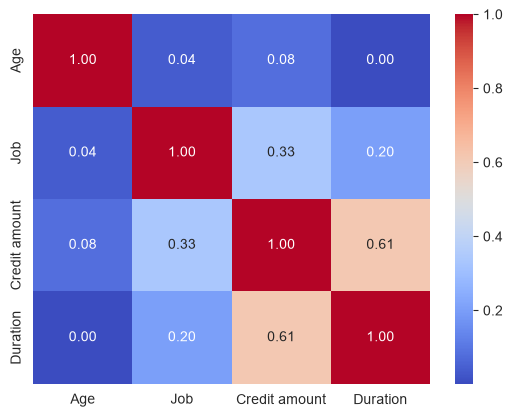

In [44]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

It says if people are taking more loan amount, they are going for high duration

In [47]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [48]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [49]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


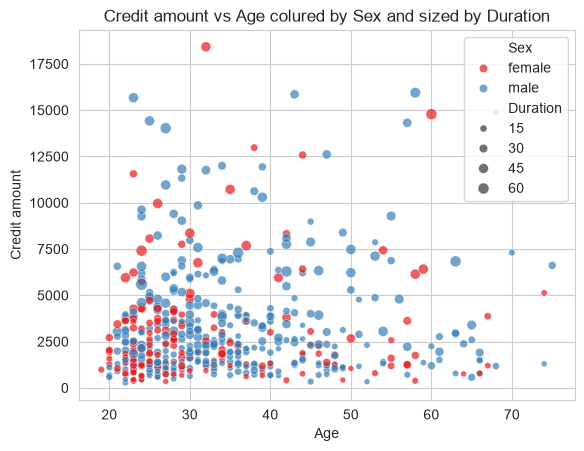

In [50]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs Age colured by Sex and sized by Duration")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\981938804.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="Saving accounts", y="Credit amount",palette="Pastel1")


Text(0.5, 1.0, 'Credit amount distribution by Savings account')

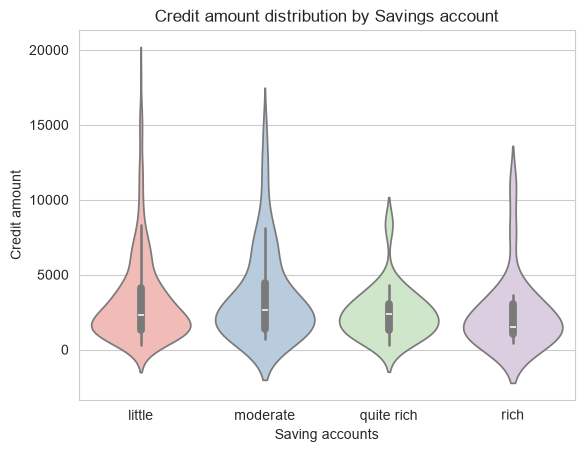

In [54]:
sns.violinplot(data=df,x="Saving accounts", y="Credit amount",palette="Pastel1")
plt.title("Credit amount distribution by Savings account")

Lets do analysis with risk

In [58]:
df["Risk"].value_counts(normalize=True)*100 #to get the percentage

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\3982991960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk",y=col,palette="Pastel2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\3982991960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk",y=col,palette="Pastel2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\3982991960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk",y=col,palette="Pastel2")


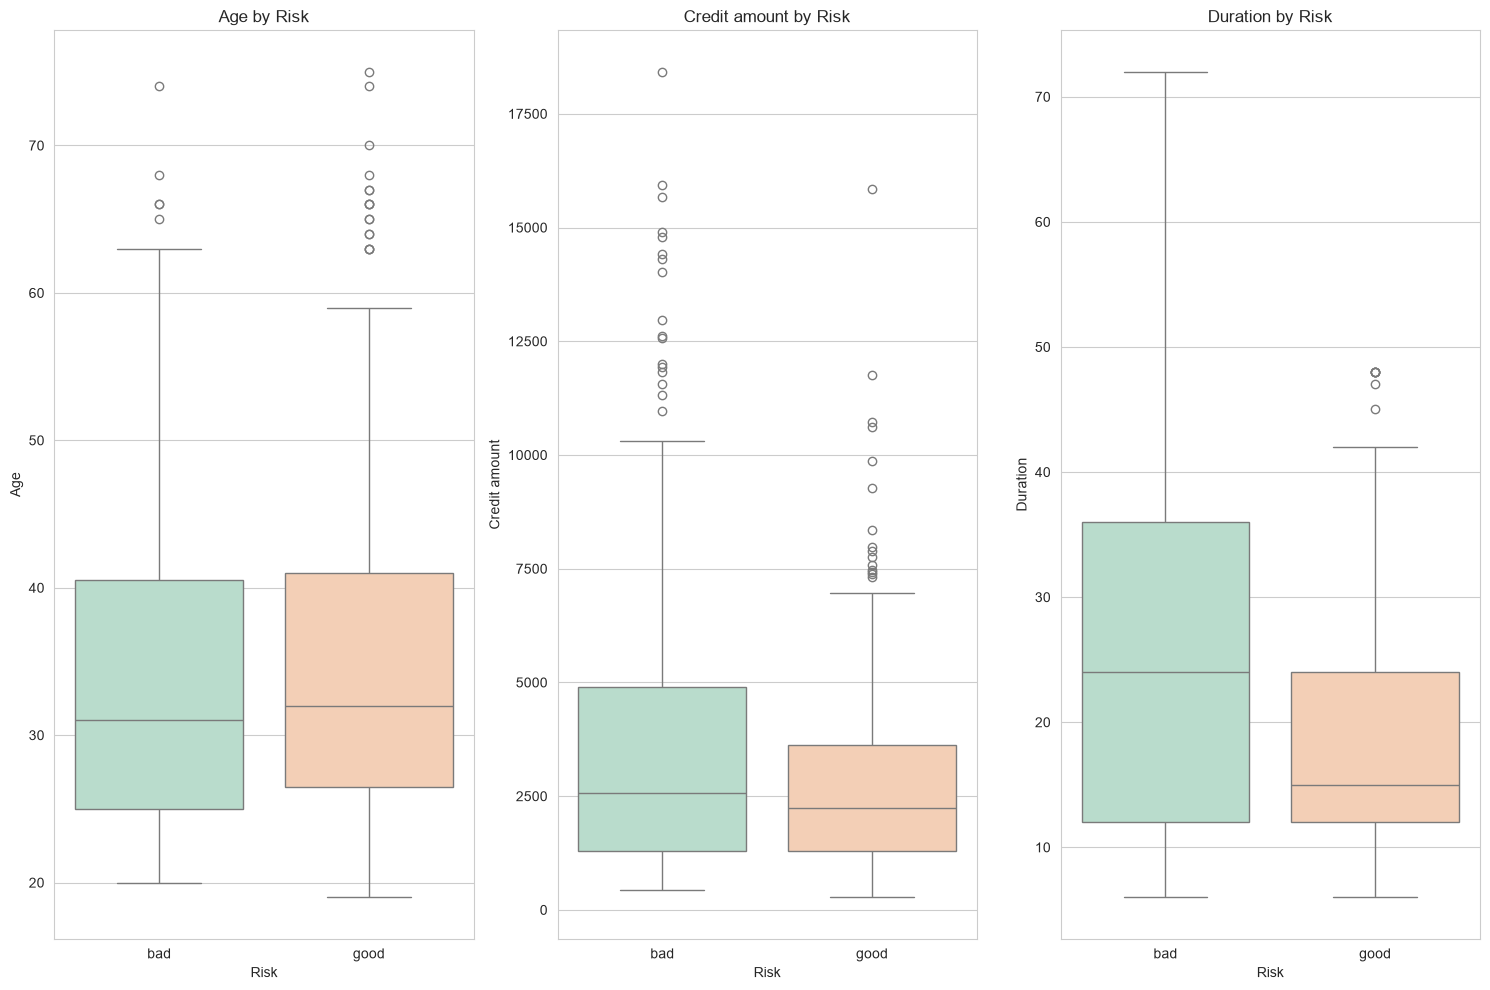

In [61]:
plt.figure(figsize=(15,10))
for i,col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=col,palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()


In [63]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [59]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

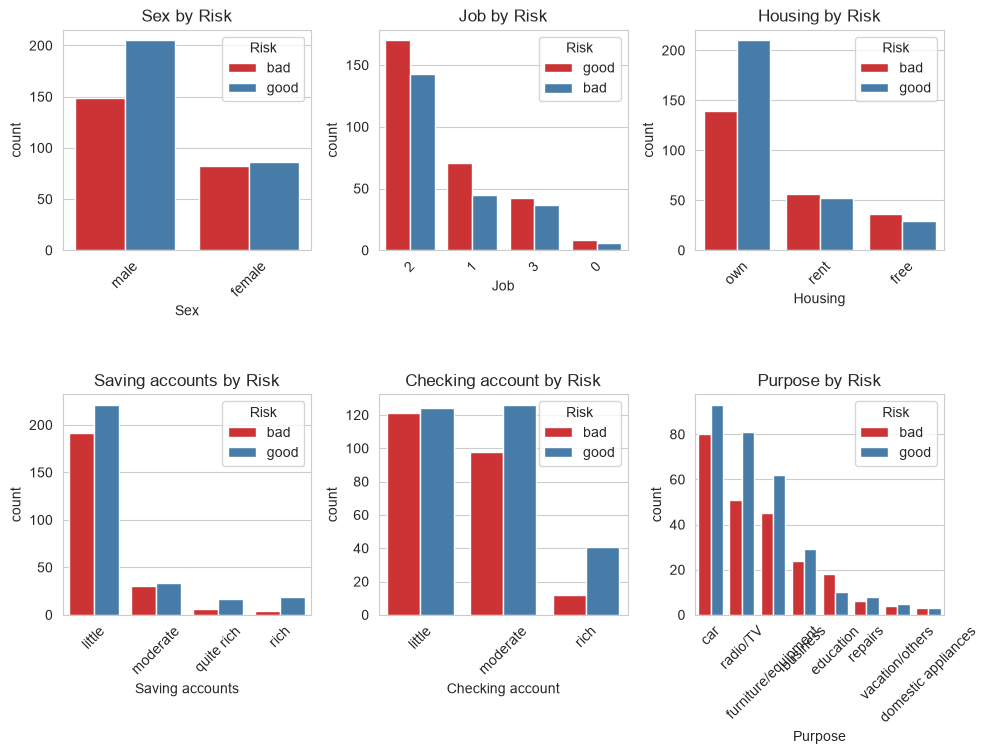

In [66]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering

In [67]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [68]:
features =['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration']

In [72]:
target="Risk"

In [73]:
df_model=df[features + [target]].copy()

In [74]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [79]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [81]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

C:\Users\DELL\AppData\Local\Temp\ipykernel_12188\2637306855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")


In [82]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [83]:
label_encoder={}

In [ ]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    label_encoder[col]=le
    joblib.dump(le,f"{col}_encoder.pkl")

In [86]:
le_target=LabelEncoder()

In [87]:
target

'Risk'

In [88]:
df_model[target]=le_target.fit_transform(df_model[target])

In [91]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [92]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [93]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0
